# a07 Example - Bayesian Optimization using Ax over Laser-Fiber Alignment Benchtop: Local Search

# Install External Libraries for Optimizer Implementation

In [1]:
# !python -m pip install ax-platform

# Imports

In [2]:
import matplotlib.pyplot as plt
# from time import sleep

import pyscan as ps
# from pyscan.drivers.thorlabs.thorlabsct1p import ThorlabsCT1P # fiber z-stage
from pyscan.drivers.thorlabs.thorlabspm16_120 import ThorlabsPM16_120 # laser power meter

from laser_fiber_align_measure_functions import grad_asc

## Setup devices

In [3]:
devices = ps.ItemAttribute()


devices.x1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 1)
devices.y1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 2)

devices.x2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 1)
devices.y2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 2)

devices.pm16_120 = ThorlabsPM16_120()

devices.laser = ps.PulseLaser('COM7')

COM7


## Define a measure function

In [4]:
def measure_power(expt):
    d = ps.ItemAttribute()
    d.power_pre_ga = devices.pm16_120.power
    grad_asc(expt.devices)
    d.voltage_x1_ga = devices.x1.voltage
    d.voltage_y1_ga = devices.y1.voltage
    d.voltage_x2_ga = devices.x2.voltage
    d.voltage_y2_ga = devices.y2.voltage
    d.power_ga = devices.pm16_120.power
    return d

# Define live plot

In [5]:
@ps.live_plot
def plot_optim_live(expt):
    global fig, axs
    axs[0].clear()
    axs[0].plot(list(zip(
                  expt.x1_voltage,
                  expt.y1_voltage,
                  expt.x2_voltage,
                  expt.y2_voltage)))
    axs[0].legend(['x1', 'y1', 'x2', 'y2'], loc='center left', bbox_to_anchor=(1, 0.5))
    axs[0].set_xlabel("optimizer step")
    axs[0].set_ylabel("instrument input")
    axs[0].set_title("Instrument Inputs as a Function of Optimizer Step");
    axs[1].clear()
    axs[1].plot(expt.power_ga)
    axs[1].set_xlabel("optimizer step")
    axs[1].set_ylabel("laser power")
    axs[1].set_title("Laser Power as a Function of Optimizer Step");

# Define runinfo

In [6]:
runinfo = ps.RunInfo()
runinfo.measure_function = measure_power

# Implement `AbstractOptimizeScan` with `AxOptimizeScan`

# Instantiate OptimizeScan

In [7]:
# z0 = 0.
# zf = 100.
# v0 = -3.
# vf = 3.
# vb = (v0, vf)
x1v0 = -0.8
x1vf = -0.6
y1v0 = 1.8
y1vf = 2.0
x2v0 = 0.9
x2vf = 1.1
y2v0 = 1.0
y2vf = 1.2

In [8]:
# z_p = ps.AxOptimizeDeviceProperty('ct10', 'position', 0, (z0, zf),
#                                   optimizer_input='z_p_readout',
#                                   initialization_scans=None)
x1 = ps.AxOptimizeDeviceProperty('x1', 'voltage', -0.7, (x1v0, x1vf),
                                 optimizer_input='x1_voltage',
                                 type='float',
                                 initialization_scans=[-0.7])
y1 = ps.AxOptimizeDeviceProperty('y1', 'voltage', 1.9, (y1v0, y1vf),
                                 optimizer_input='y1_voltage',
                                 type='float',
                                 initialization_scans=[1.89])
x2 = ps.AxOptimizeDeviceProperty('x2', 'voltage', 1.0, (x2v0, x2vf),
                                 optimizer_input='x2_voltage',
                                 type='float',
                                 initialization_scans=[1.04])
y2 = ps.AxOptimizeDeviceProperty('y2', 'voltage', 1.1, (y2v0, y2vf),
                                 optimizer_input='y2_voltage',
                                 type='float',
                                 initialization_scans=[1.12])

In [9]:
runinfo.scan0 = ps.AxOptimizeScan((x1, y1, x2, y2),
                                  'power_ga',
                                  dt=1., n_max=25,
                                  global_improvement_threshold=1e-5,
                                  global_improvement_index_window=5,
                                  global_improvement_start_index=10,
                                  extremum='max')

# Run Experiments

In [10]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

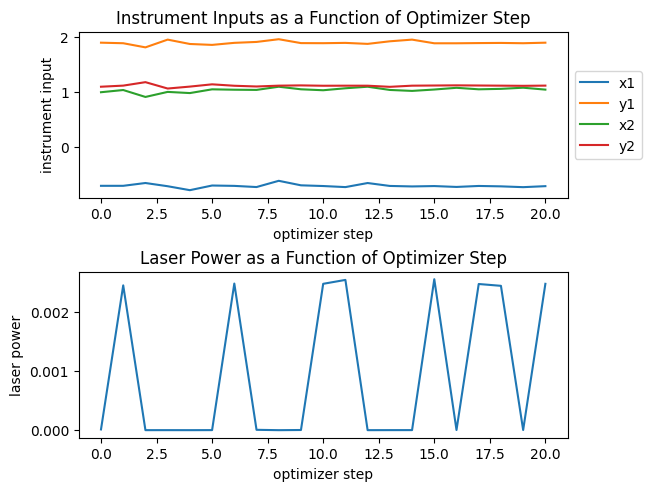

In [11]:
fig, axs = plt.subplots(2, layout='constrained')
try:
    plot_optim_live(expt)
except KeyboardInterrupt:
    expt.stop()

In [13]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x27b44572930>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x27b13f39220>,
 'expt_thread': <Thread(Thread-3 (run), stopped daemon 21636)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21.]),
 'x1_voltage': array([-0.7       , -0.7       , -0.64901901, -0.70750907, -0.77921871,
        -0.69459781, -0.70124085, -0.72241345, -0.60908195, -0.69110777,
        -0.70390305, -0.72332808, -0.64942355, -0.70235538, -0.71133383,
        -0.70456484, -0.72034854, -0.70264456, -0.70983663, -0.72442898,
        -0.70624674, -0.70456484]),
 'y1_voltage': array([1.9       , 1.89      , 1.81481038, 1.95562242, 1.87637732,
        1.85976189, 1.89700788, 1.91355974, 1.96294438, 1.89223296,
        1.89075784, 1.89625142, 1.87819411, 1.9251458 , 1.95557787,
        1.88903514, 1.88910823, 1.89284933, 1.8954621 , 1.89005092,
        1.89991106, 1.88

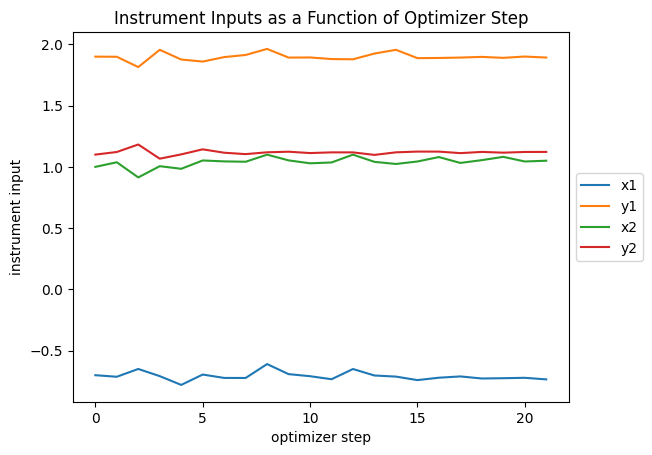

In [14]:
plt.plot(list(zip(
                  expt.voltage_x1_ga,
                  expt.voltage_y1_ga,
                  expt.voltage_x2_ga,
                  expt.voltage_y2_ga)))
plt.legend(['x1', 'y1', 'x2', 'y2'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel("optimizer step")
plt.ylabel("instrument input")
plt.title("Instrument Inputs as a Function of Optimizer Step");

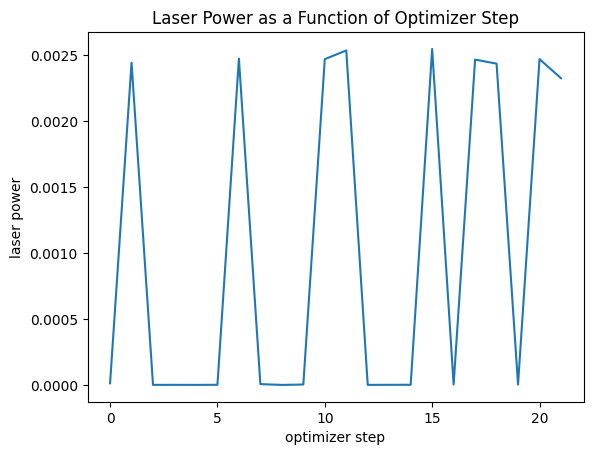

In [15]:
plt.plot(expt.power_ga)
plt.xlabel("optimizer step")
plt.ylabel("laser power")
plt.title("Laser Power as a Function of Optimizer Step");